In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize,word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.feature_extraction.text import CountVectorizer



In [42]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')     

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\20100\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\20100\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\20100\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\20100\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Reading the data

In [119]:
data = pd.read_csv('news-article-categories.csv')

# EDA

In [120]:
data.head()

,category,title,body
0,ARTS & CULTURE,Modeling Agencies Enabled Sexual Predators For...,"In October 2017, Carolyn Kramer received a dis..."
1,ARTS & CULTURE,Actor Jeff Hiller Talks “Bright Colors And Bol...,This week I talked with actor Jeff Hiller abou...
2,ARTS & CULTURE,New Yorker Cover Puts Trump 'In The Hole' Afte...,The New Yorker is taking on President Donald T...
3,ARTS & CULTURE,Man Surprises Girlfriend By Drawing Them In Di...,"Kellen Hickey, a 26-year-old who lives in Huds..."
4,ARTS & CULTURE,This Artist Gives Renaissance-Style Sculptures...,There’s something about combining the traditio...


In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6877 entries, 0 to 6876
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  6877 non-null   object
 1   title     6877 non-null   object
 2   body      6872 non-null   object
dtypes: object(3)
memory usage: 161.3+ KB


In [122]:
data.isna().sum()

category    0
title       0
body        5
dtype: int64

In [123]:
data.dropna(inplace=True)

In [124]:
data.duplicated().sum()

28

In [125]:
data.drop_duplicates(inplace=True)

In [126]:
data['text']=data['title']+" "+data['body']
data.drop(columns=['title','body'],inplace=True)

In [127]:
data

,category,text
0,ARTS & CULTURE,Modeling Agencies Enabled Sexual Predators For...
1,ARTS & CULTURE,Actor Jeff Hiller Talks “Bright Colors And Bol...
2,ARTS & CULTURE,New Yorker Cover Puts Trump 'In The Hole' Afte...
3,ARTS & CULTURE,Man Surprises Girlfriend By Drawing Them In Di...
4,ARTS & CULTURE,This Artist Gives Renaissance-Style Sculptures...
...,...,...
6872,WOMEN,Casually Fearless: Why Millennials Are Natural...
6873,WOMEN,Happy Birthday To Us I remember the morning of...
6874,WOMEN,"The Culture of Love My husband, Gene, doesn't ..."
6875,WOMEN,"Carpe Diem, Oprah Style \nBy AntonioGuillem, v..."


In [128]:
data['category'].value_counts()

category
ARTS & CULTURE    1000
BUSINESS           501
POLITICS           501
RELIGION           501
SPORTS             501
TECH               501
WOMEN              501
ENTERTAINMENT      497
EDUCATION          490
ENVIRONMENT        480
COMEDY             376
SCIENCE            350
MEDIA              346
CRIME              299
Name: count, dtype: int64

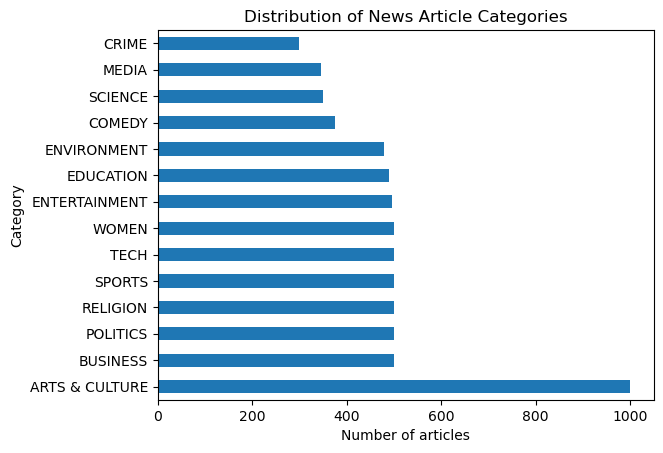

In [129]:
data['category'].value_counts().plot(kind='barh')
plt.xlabel('Number of articles')
plt.ylabel('Category')
plt.title('Distribution of News Article Categories')    
plt.show()

# To Solve Imbalance, Smote Oversampling does not perform well in high dimentions

![Text-augmentation-techniques-in-NLP-1-(1)-660.png](attachment:Text-augmentation-techniques-in-NLP-1-(1)-660.png)
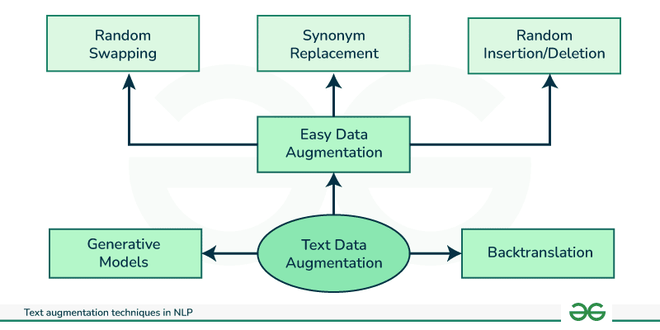

# Preprocessing the Text

In [130]:
X = data.drop("category", axis=1)
y = data["category"]


In [131]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [132]:
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

In [133]:
def preprocess(text):
    '''function to preprocess the text data
    1)    Converting the text to lowercase
    2)    Removing non-word characters
    3)   Removing extra spaces
    4)   Tokenization
    5)   Removing stop words
    6)   Lemmatization
    7)   Joining the tokens back to form the string    
    '''
    text = text.lower()

    text=re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) #remove URls
    text=re.sub(r'\@\w+|\#', '', text)                                    #remove special chars
    text=re.sub(r'[^a-zA-z\s]','',text)                                   #remove numbers

    tokens = word_tokenize(text)
    clean_tokens=[lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word)>2]
    
    return ' '.join(clean_tokens)

In [134]:
xtrain['clean_text']=xtrain['text'].apply(preprocess)

xtest['clean_text']=xtest['text'].apply(preprocess)

In [135]:
ytrain.value_counts()

category
ARTS & CULTURE    800
RELIGION          401
BUSINESS          401
TECH              401
WOMEN             401
POLITICS          401
SPORTS            400
ENTERTAINMENT     397
EDUCATION         392
ENVIRONMENT       384
COMEDY            301
SCIENCE           280
MEDIA             277
CRIME             239
Name: count, dtype: int64

In [136]:
class_map = {
    "ARTS & CULTURE": 1,
    "RELIGION": 2,
    "BUSINESS": 3,
    "TECH": 4,
    "WOMEN": 5,
    "POLITICS": 6,
    "SPORTS": 7,
    "ENTERTAINMENT": 8,
    "EDUCATION": 9,
    "ENVIRONMENT": 10,
    "COMEDY": 10,
    "SCIENCE": 10,
    "MEDIA": 10,
    "CRIME": 10,

}


In [137]:
ytrain = ytrain.map(class_map)
ytest = ytest.map(class_map)

In [138]:
ytrain

1749    10
1802    10
2939     8
3991    10
1613    10
        ..
709      1
5812     7
3812    10
3513    10
3678    10
Name: category, Length: 5475, dtype: int64

In [139]:
xtrain

,text,clean_text
1749,Alec Baldwin: It's Tough To Impersonate The Gr...,alec baldwin tough impersonate greatest presid...
1802,Comedian Just Needs To Know How Racist McDonal...,comedian need know racist mcdonalds want voice...
2939,Kim Kardashian Explains Why The Name Chicago ‘...,kim kardashian explains name chicago kind mess...
3991,Geraldo Rivera Says Women 'May Be Criminalizin...,geraldo rivera say woman may criminalizing cou...
1613,"Trevor Noah: If I Supported Donald Trump, This...",trevor noah supported donald trump new revelat...
...,...,...
709,Susan Lizotte: Blood & Treasure \r\nSusan Lizo...,susan lizotte blood treasure susan lizotte kin...
5812,"LeBron James Talks Vandalism, Racism: ‘Being B...",lebron james talk vandalism racism black ameri...
3812,Watch A Trump Backer’s Painfully Dumb Joke Sta...,watch trump backer painfully dumb joke startle...
3513,Obama's Keystone XL Trade-Off: Executive Order...,obamas keystone tradeoff executive order exped...


# Feature Extraction

## TF-IDF

In [140]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(xtrain['clean_text'])
X_test_tfidf = vectorizer.transform(xtest['clean_text'])

In [141]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(), 
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
}


In [142]:
results = {}
for model_name, model in models.items():
    model.fit(X_train_tfidf, ytrain)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(ytest, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(ytest, y_pred))
    print("-" * 50)
    results[model_name] = accuracy
    
    

Multinomial Naive Bayes Accuracy: 0.4054


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.91      0.68      0.78       200
           2       1.00      0.12      0.21       100
           3       0.50      0.02      0.04       100
           4       0.75      0.03      0.06       100
           5       1.00      0.01      0.02       100
           6       1.00      0.01      0.02       100
           7       1.00      0.07      0.13       101
           8       0.00      0.00      0.00       100
           9       0.92      0.23      0.37        98
          10       0.32      1.00      0.48       370

    accuracy                           0.41      1369
   macro avg       0.74      0.22      0.21      1369
weighted avg       0.67      0.41      0.31      1369

--------------------------------------------------
Logistic Regression Accuracy: 0.7823
              precision    recall  f1-score   support

           1       0.84      0.92      0.87       200
           2       0.92      0.80      0.86 

In [143]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Accuracy
Logistic Regression,0.782323
Support Vector Machine,0.769905
Random Forest,0.680058
Multinomial Naive Bayes,0.405405


In [ ]:
results_df.plot(kind='barh', legend=False)
plt.xlabel('Accuracy')

In [144]:
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

In [145]:
model= Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(11, activation='softmax')  # Assuming 10 classes + 1 for padding
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


d:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [146]:
history = model.fit(X_train_dense, ytrain, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 276s 181ms/step - accuracy: 0.2754 - loss: 2.2253 - val_accuracy: 0.5242 - val_loss: 1.5049
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.6011 - loss: 1.2442 - val_accuracy: 0.7699 - val_loss: 0.8065
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8406 - loss: 0.5809 - val_accuracy: 0.8055 - val_loss: 0.6575
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9181 - loss: 0.3236 - val_accuracy: 0.8137 - val_loss: 0.6225
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9664 - loss: 0.1760 - val_accuracy: 0.8174 - val_loss: 0.6354
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9700 - loss: 0.1266 - val_accuracy: 0.8146 - val_loss: 0.6511
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.9817 - loss: 0.0927 - val_accuracy: 0.8055 - val_loss: 0.6988


In [147]:
y_pred_probs = model.predict(X_test_dense)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(ytest, y_pred)
print(f"Neural Network Accuracy: {accuracy:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Neural Network Accuracy: 0.8145


## BoW

In [150]:
bow_vectorizer = CountVectorizer()

In [151]:
X_train_bow = bow_vectorizer.fit_transform(xtrain['clean_text'])
X_test_bow = bow_vectorizer.transform(xtest['clean_text'])

In [152]:
results={}
for model_name, model in models.items():
    model.fit(X_train_bow, ytrain)
    y_pred = model.predict(X_test_bow)
    accuracy = accuracy_score(ytest, y_pred)
    print(f"{model_name} (BoW) Accuracy: {accuracy:.4f}")
    print(classification_report(ytest, y_pred))
    print("-" * 50)
    results[model_name + " (BoW)"] = accuracy
    

Multinomial Naive Bayes (BoW) Accuracy: 0.7670
              precision    recall  f1-score   support

           1       0.71      0.95      0.81       200
           2       0.89      0.83      0.86       100
           3       0.69      0.66      0.67       100
           4       0.81      0.57      0.67       100
           5       0.70      0.58      0.63       100
           6       0.68      0.77      0.72       100
           7       0.96      0.81      0.88       101
           8       0.76      0.53      0.62       100
           9       0.78      0.85      0.81        98
          10       0.79      0.81      0.80       370

    accuracy                           0.77      1369
   macro avg       0.78      0.74      0.75      1369
weighted avg       0.77      0.77      0.76      1369

--------------------------------------------------
Logistic Regression (BoW) Accuracy: 0.8020
              precision    recall  f1-score   support

           1       0.87      0.88      0.88  

In [ ]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Accuracy
Logistic Regression (BoW),0.802045
Multinomial Naive Bayes (BoW),0.766983
Support Vector Machine (BoW),0.745069
Random Forest (BoW),0.673484


Text(0.5, 0, 'Accuracy')

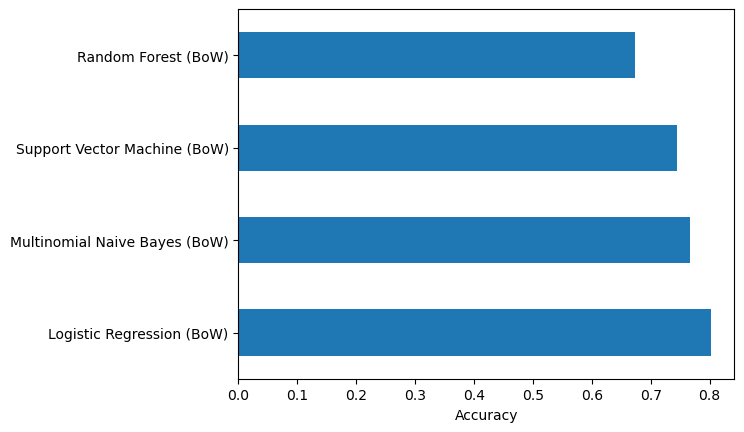

In [157]:
results_df.plot(kind='barh', legend=False)
plt.xlabel('Accuracy')

In [158]:
X_train_BoW_dense = X_train_bow.toarray()
X_test_Bow_dense = X_test_bow.toarray()

In [160]:
model_Bow=Sequential([
    Dense(128, activation='relu', input_shape=(X_train_BoW_dense.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(11, activation='softmax')  
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

d:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
history_Bow=model.fit(X_train_BoW_dense, ytrain, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 271s 703ms/step - accuracy: 0.3440 - loss: 2.0244 - val_accuracy: 0.7580 - val_loss: 0.9154
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.7220 - loss: 0.9447 - val_accuracy: 0.7991 - val_loss: 0.7326
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.8549 - loss: 0.5213 - val_accuracy: 0.8009 - val_loss: 0.7627
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.8979 - loss: 0.3642 - val_accuracy: 0.8146 - val_loss: 0.7433
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9342 - loss: 0.2431 - val_accuracy: 0.8100 - val_loss: 0.8097


In [163]:
y_pred_probs_Bow = model_Bow.predict(X_test_Bow_dense)
y_pred_Bow = np.argmax(y_pred_probs_Bow, axis=1)    
accuracy_Bow = accuracy_score(ytest, y_pred_Bow)
print(f"Neural Network (BoW) Accuracy: {accuracy_Bow}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Neural Network (BoW) Accuracy: 0.05697589481373265
